# Create Images of Ship Sprites

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

Load in the sprite data

In [2]:
import re
from colors_map import *

sprites_files = ["uridium/src/ship_sprites.asm"]
sprites_data = {}
for sprites_file in sprites_files:
    input_file = open(sprites_file,'r')
    sprite_data = []
    for l in input_file.readlines():
        if "SPRITE" in l:
            if sprite_data:
                sprites_data[sprite_name] = sprite_data
            sprite_name = l[22:36].strip()
            sprite_data = []
            continue

        m = re.findall(r"[0-1]{24}",l)
        if not m:
            continue
        bits = m[0]
        sprite_line = []
        for i in range(0,23,2):
            bitpair = bits[i:i+2]
            sprite_line += [bitpair]
            sprite_line += [bitpair]
        sprite_data += [sprite_line]
    if sprite_data:
        sprites_data[sprite_name] = sprite_data

Function for actually drawing the sprite

In [3]:
from PIL import Image, ImageColor
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintSprite(sprite, colors):
    multicol0, multicol1,color = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    
    if sprite not in sprites_data:
        print(sprite)
        return
    
    image_width = SPRITE_COLS
    image_height = SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    pixels = img.load()

    bit_array = sprites_data[sprite]
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img


In [4]:
colors = (
    # cell color, text color
     "c64_yellow",
     "c64_white",
     "c64_black", 
)
sprite_images = []
sprite_frames = {}
for sprite_name in sprites_data:
    img = paintSprite(sprite_name, colors)
    sprite_images += [img]
    if sprite_name:
        sprite_frames[sprite_name] = img
        img.save(f"manta_spin_diagrams/{sprite_name}.png")
sprite_images[1]

In [5]:
animations = {}
animations["mantaRollRightFrom90Degrees"] = ["MANTA_RIGHT_13", "MANTA_RIGHT_14", "MANTA_RIGHT_15", "MANTA"]
animations["mantaRollLeftFromUpsideDown"] = ["MANTA_RIGHT_5", "MANTA_RIGHT_4", "MANTA_RIGHT_3", "MANTA_2"]
animations["mantaRollLeft1"] = ["MANTA1", "MANTA_2", "MANTA_RIGHT_3", "MANTA_RIGHT_4"]
animations["mantaRollLeft"] = ["MANTA1", "MANTA_2", "MANTA_RIGHT_3", "MANTA_RIGHT_4"]

animations["mantaFlipFromRightToLeft"] = [
    "MANTA_LEFT_9", "MANTA_LEFT_8", "MANTA_LEFT_7", "MANTA_LEFT_6", "MANTA_LEFT_5", "MANTA_LEFT_4",
    "MANTA_LEFT_3", "MANTA_LEFT_2", "MANTA_LEFT_1", "MANTA_FLIP_6", "MANTA_FLIP_5", "MANTA_FLIP_4", "MANTA_FLIP_3",
    "MANTA_FLIP_2", "MANTA_FLIP_1", "MANTA_FLIP_0" ]
animations["mantaRollFacingRight"] = [
    "MANTA1", "MANTA", "MANTA_RIGHT_15", "MANTA_RIGHT_14", "MANTA_RIGHT_13", "MANTA_RIGHT_12", "MANTA_RIGHT_11",
    "MANTA_RIGHT_10", "MANTA_RIGHT_9", "MANTA_RIGHT_8", "MANTA_RIGHT_7", "MANTA_RIGHT_6", "MANTA_RIGHT_5", "MANTA_RIGHT_4", "MANTA_RIGHT_3",
    "MANTA_2"]

animations["mantaRollLeft90DegreesFacingLeft"] = ["MANTA_LEFT_5", "MANTA_LEFT_6", "MANTA_LEFT_7", "MANTA_LEFT_8"]
animations["mantaRollRight90DegreesFacingLeft"] = ["MANTA_LEFT_13", "MANTA_LEFT_12", "MANTA_LEFT_11", "MANTA_LEFT_10"]
animations["mantaRollRightFrom180DegreesFacingLeft"] = ["MANTA_LEFT_9", "MANTA_LEFT_8", "MANTA_LEFT_7", "MANTA_LEFT_6"]
animations["mantaRollLeftFrom180DegreesFacingLeft"] = ["MANTA_LEFT_9", "MANTA_LEFT_10", "MANTA_LEFT_11", "MANTA_LEFT_12"]
animations["mantaRollAndFlipLeft"] = ["MANTA1", "MANTA", "MANTA_RIGHT_15", "MANTA_RIGHT_14", "MANTA_RIGHT_13", "MANTA_RIGHT_12", "MANTA_RIGHT_11",
    "MANTA_RIGHT_10", "MANTA_RIGHT_9", "MANTA_FLIP_7", "MANTA_FLIP_8", "MANTA_FLIP_9", "MANTA_FLIP_10", "MANTA_FLIP_11", "MANTA_FLIP_12",
    "MANTA_FLIP_13"]
animations["manta360RollLeft"] = [
    "MANTA_LEFT_9", "MANTA_LEFT_8", "MANTA_LEFT_7", "MANTA_LEFT_6", "MANTA_LEFT_5", "MANTA_LEFT_4", "MANTA_LEFT_3",
    "MANTA_LEFT_2", "MANTA_LEFT_1", "MANTA_LEFT_0", "MANTA_LEFT_15", "MANTA_LEFT_14", "MANTA_LEFT_13", "MANTA_LEFT_12", "MANTA_LEFT_11",
    "MANTA_LEFT_10"]



## A graphic showing the spin animation

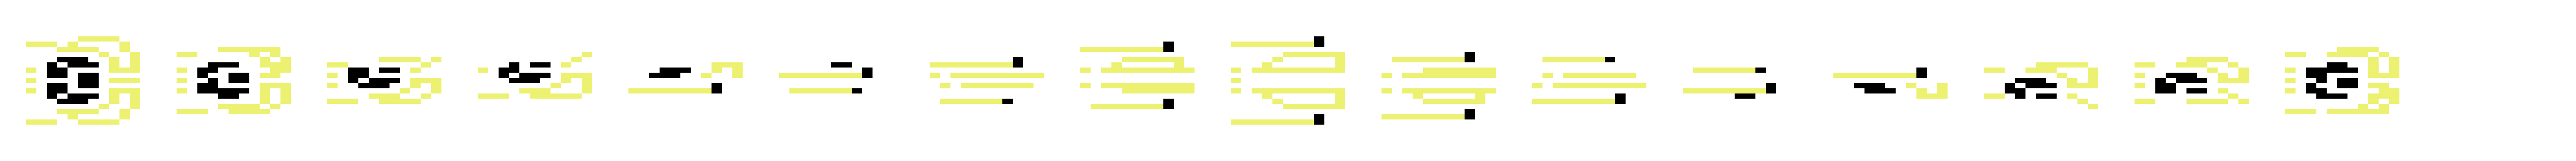

In [6]:
master_width = ((SPRITE_COLS + 7) * 16)
master_height = SPRITE_ROWS + 10
master_img = Image.new( 'RGBA', (master_width, master_height))
x_offset = 5
for sprite_name in animations["manta360RollLeft"]:
    img = sprite_frames[sprite_name]
    master_img.paste(img, (x_offset,5))
    x_offset += SPRITE_COLS + 5
master_img = master_img.resize((master_img.width * 10, master_img.height * 10), Image.NEAREST)
master_img


# Scratchpad